# **Required Lib**

In [3]:
!pip install kagglehub statsmodels

# **Importing the lib**

In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# **Dataset**

In [5]:
path = kagglehub.dataset_download(
    "uciml/electric-power-consumption-data-set"
)

print(path)

100%|██████████| 19.4M/19.4M [00:02<00:00, 8.39MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/uciml/electric-power-consumption-data-set/versions/1


# **Loading the dataset**

In [6]:
import os

file_path = os.path.join(
    path,
    "household_power_consumption.txt"
)

df = pd.read_csv(
    file_path,
    sep=';',
    low_memory=False
)

df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


# **Data Preprocessing**

In [7]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True
)

df.set_index(
    'Datetime',
    inplace=True
)

# **Forecast Variable**

In [8]:
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],
    errors='coerce'
)

power = df['Global_active_power']

# **Missing Value**

In [9]:
power = power.fillna(
    method='ffill'
)

/tmp/ipykernel_604/3648183386.py:1: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  power = power.fillna(


# **Minute data into Daily Data**

In [10]:
daily_power = power.resample(
    'D'
).mean()

daily_power.head()

,Global_active_power
Datetime,
2006-12-16,3.053475
2006-12-17,2.354486
2006-12-18,1.530435
2006-12-19,1.157079
2006-12-20,1.545658


# **Visualiaze the data**

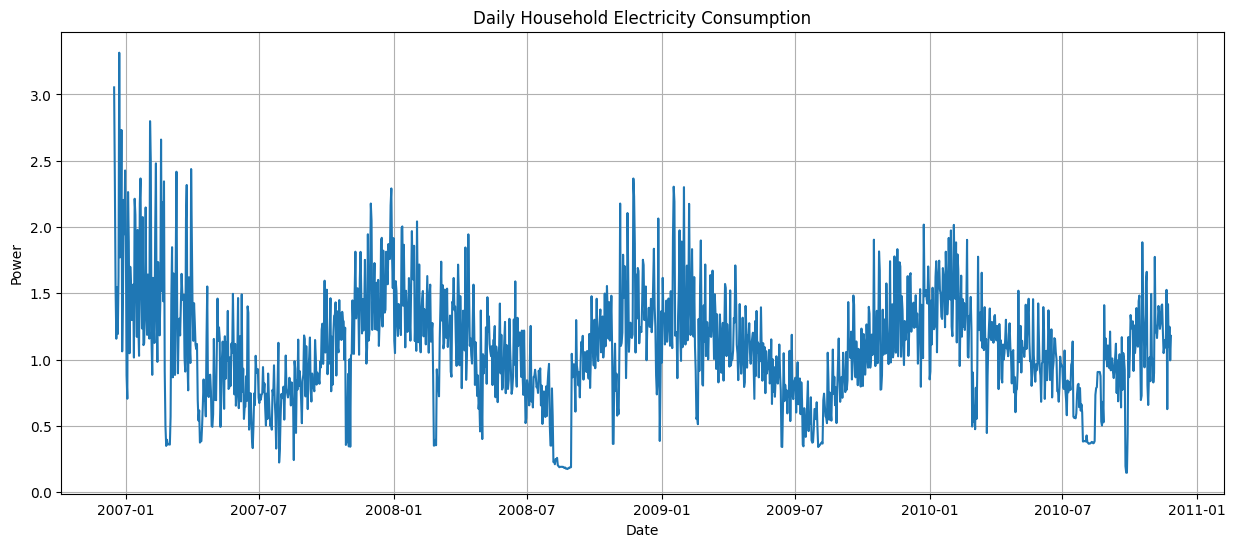

In [11]:
plt.figure(figsize=(15,6))

plt.plot(daily_power)

plt.title(
    "Daily Household Electricity Consumption"
)

plt.xlabel("Date")
plt.ylabel("Power")

plt.grid(True)

plt.show()

# **Train Test Split**

In [12]:
train = daily_power[:-365]

test = daily_power[-365:]

print("Training:", len(train))
print("Testing:", len(test))

Training: 1077
Testing: 365


# **METHODS**

### **1.) SIMPLE EXPONENTIAL SMOOTHING (SES)**

In [13]:
ses_model = SimpleExpSmoothing(
    train
).fit(
    optimized=True
)

ses_forecast = ses_model.forecast(
    len(test)
)

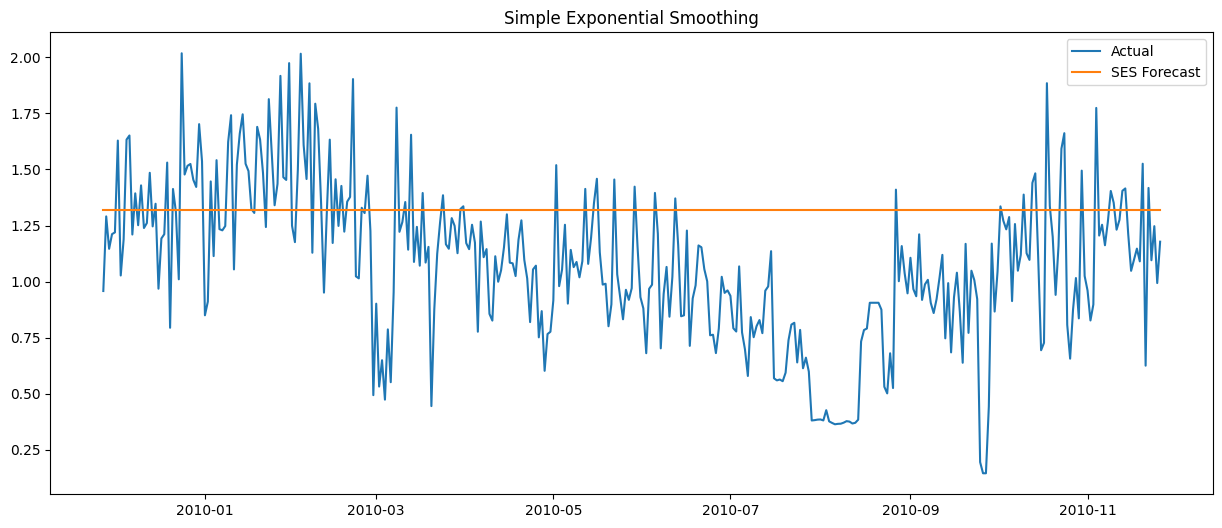

In [14]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    ses_forecast,
    label='SES Forecast'
)

plt.legend()

plt.title(
    "Simple Exponential Smoothing"
)

plt.show()

### **2.) HOLT'S LINEAR TREND METHOD**

In [15]:
holt_model = Holt(
    train
).fit(
    optimized=True
)

holt_forecast = holt_model.forecast(
    len(test)
)

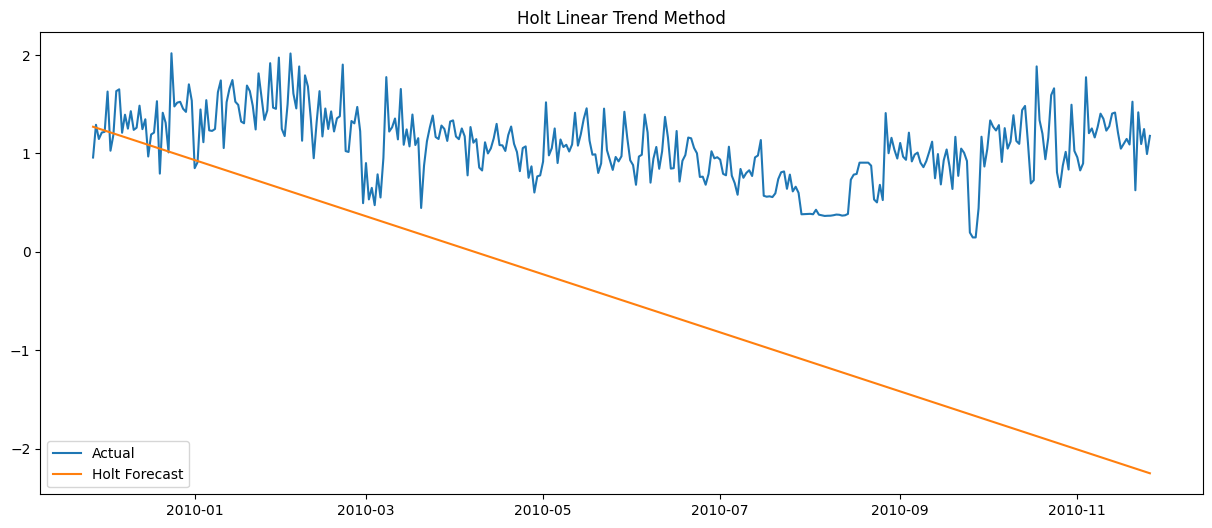

In [16]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    holt_forecast,
    label='Holt Forecast'
)

plt.legend()

plt.title(
    "Holt Linear Trend Method"
)

plt.show()

### **3.) HOLT-WINTERS ADDITIVE**

In [17]:
hw_add_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=365
).fit()

hw_add_forecast = hw_add_model.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


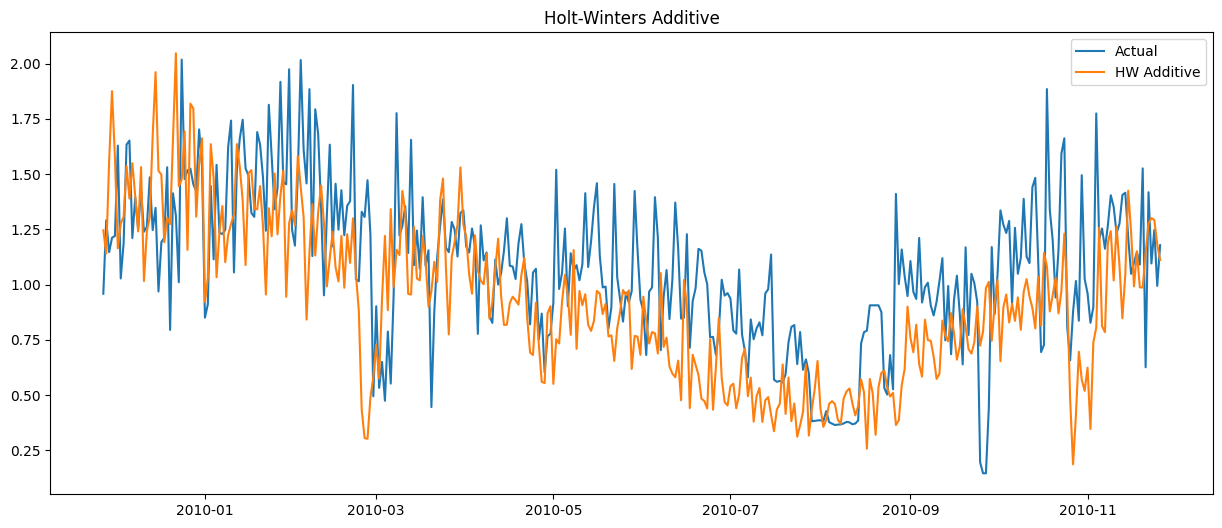

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    hw_add_forecast,
    label='HW Additive'
)

plt.legend()

plt.title(
    "Holt-Winters Additive"
)

plt.show()

### **4.) HOLT-WINTERS MULTIPLICATIVE**

In [19]:
hw_mul_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=365
).fit()

hw_mul_forecast = hw_mul_model.forecast(
    len(test)
)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


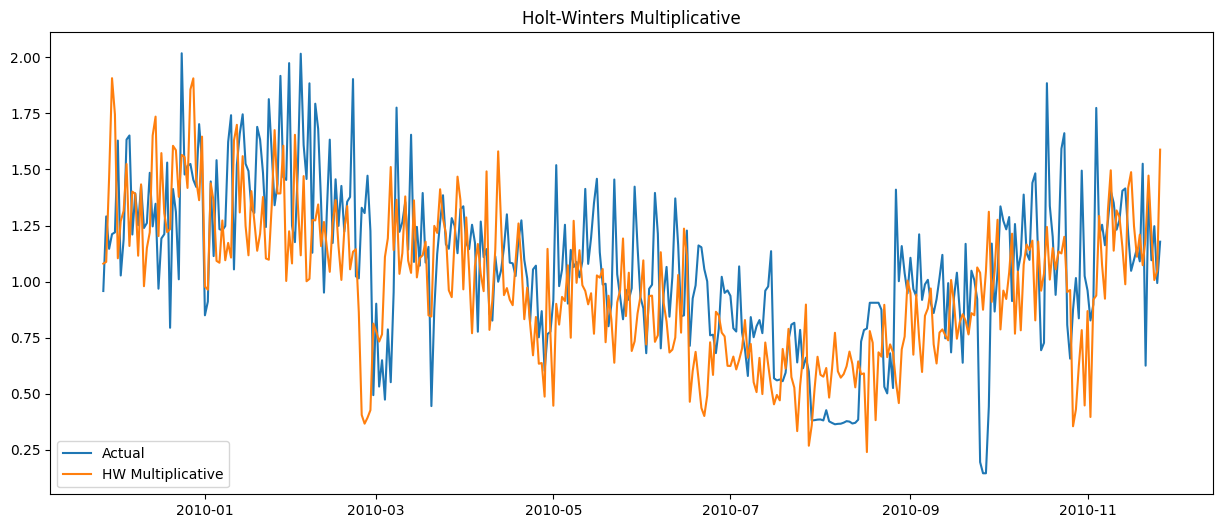

In [20]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    hw_mul_forecast,
    label='HW Multiplicative'
)

plt.legend()

plt.title(
    "Holt-Winters Multiplicative"
)

plt.show()

# **Comapring all the MAE and RMSE**

In [21]:
def evaluate(
    actual,
    predicted,
    model_name
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    print("\n", model_name)

    print("MAE :", mae)

    print("RMSE:", rmse)


evaluate(
    test,
    ses_forecast,
    "Simple Exponential Smoothing"
)

evaluate(
    test,
    holt_forecast,
    "Holt Linear Trend"
)

evaluate(
    test,
    hw_add_forecast,
    "Holt-Winters Additive"
)

evaluate(
    test,
    hw_mul_forecast,
    "Holt-Winters Multiplicative"
)


 Simple Exponential Smoothing
MAE : 0.342965309522378
RMSE: 0.42693138172216283

 Holt Linear Trend
MAE : 1.5741178619332685
RMSE: 1.826559940670387

 Holt-Winters Additive
MAE : 0.28132041419060166
RMSE: 0.35612356321315675

 Holt-Winters Multiplicative
MAE : 0.27027855928672134
RMSE: 0.34274805461007607


# **Comparision Graph**

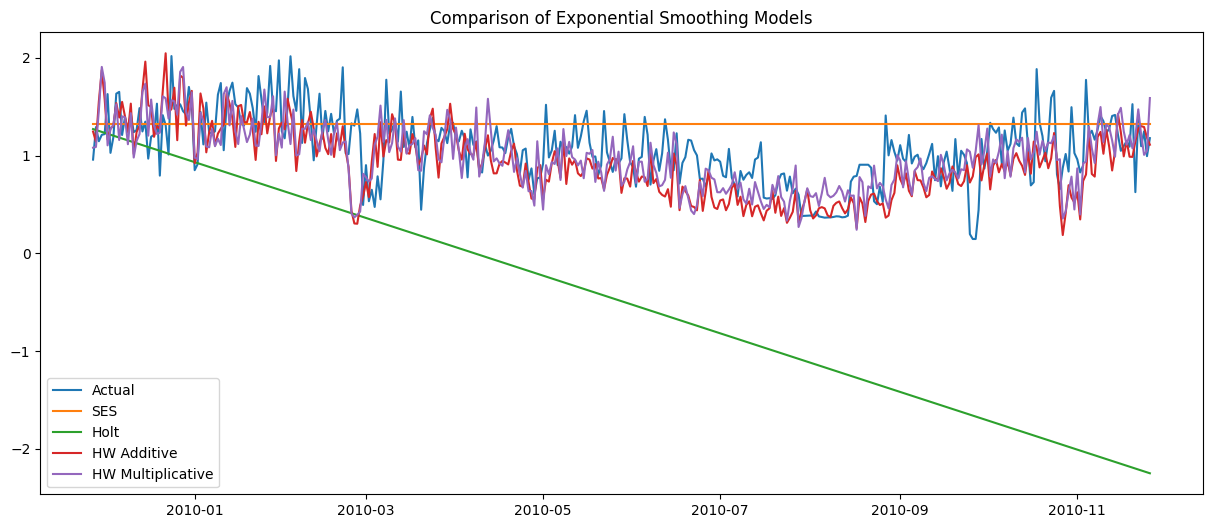

In [22]:
plt.figure(figsize=(15,6))

plt.plot(
    test.index,
    test,
    label='Actual'
)

plt.plot(
    test.index,
    ses_forecast,
    label='SES'
)

plt.plot(
    test.index,
    holt_forecast,
    label='Holt'
)

plt.plot(
    test.index,
    hw_add_forecast,
    label='HW Additive'
)

plt.plot(
    test.index,
    hw_mul_forecast,
    label='HW Multiplicative'
)

plt.legend()

plt.title(
    "Comparison of Exponential Smoothing Models"
)

plt.show()

# **Evaluation**

| Rank | Model                        | Performance |
| ---- | ---------------------------- | ----------- |
| 1    | Holt-Winters Multiplicative  | Best        |
| 2    | Holt-Winters Additive        | Very Good   |
| 3    | Simple Exponential Smoothing | Moderate    |
| 4    | Holt Linear Trend            | Poor        |